# Alimentación del brazo: consumo eléctrico y dimensionamiento de la fuente

**Taller de Proyecto I (E0306) — 2.º cuatrimestre 2026 — Grupo N.º 4**

---

## Alcance de este documento

Este cuaderno cierra la parte eléctrica del proyecto: **de dónde sale la energía
y cuánta hace falta**. Responde cuatro preguntas:

1. A qué tensión alimentamos los servos.
2. Cuánta corriente consume el brazo, en régimen y en el peor instante.
3. Qué fuente hay que conseguir, y qué capacitor, cable y fusible la acompañan.
4. Qué tiene que hacer el firmware para que esos números se cumplan.

Se apoya en dos cosas ya cerradas. Del **cuaderno de dimensionamiento mecánico**
sale el par que hace cada articulación, que es lo que nos permite calcular la
corriente sin suponer el peor caso absoluto. Y del grupo sale la decisión de
usar **un único modelo de servo en las cinco articulaciones: el MG996R**.

## El servo adoptado

| Característica | Valor | |
|---|---|---|
| Par de bloqueo | **9,4 kg·cm a 4,8 V** — **11 kg·cm a 6,0 V** | |
| Tensión de operación | 4,8 a 7,2 V | |
| Corriente en marcha sin carga | 500 mA a 4,8 V — **900 mA a 6,0 V** | |
| Corriente de bloqueo | **2,5 A a 6,0 V** | |
| Masa | 55 g | |
| Velocidad | 0,14 s/60° a 6,0 V | |
| Banda muerta | 5 µs | |

Los valores son los de la hoja de datos del fabricante. Una aclaración que
conviene dejar escrita: **el MG996R es un producto de TowerPro**, no de Futaba.
Circulan clones reetiquetados de varias marcas, y suelen entregar algo menos que
la hoja de datos, así que en la sección 10 verificamos por medición.

El criterio es el mismo que en toda la parte mecánica: **calcular el peor caso y
adoptar un margen**. Todo el cálculo usa únicamente la librería `math`.

---

# 1. Qué hay que alimentar

El esquema que vamos a justificar a lo largo del documento es este:

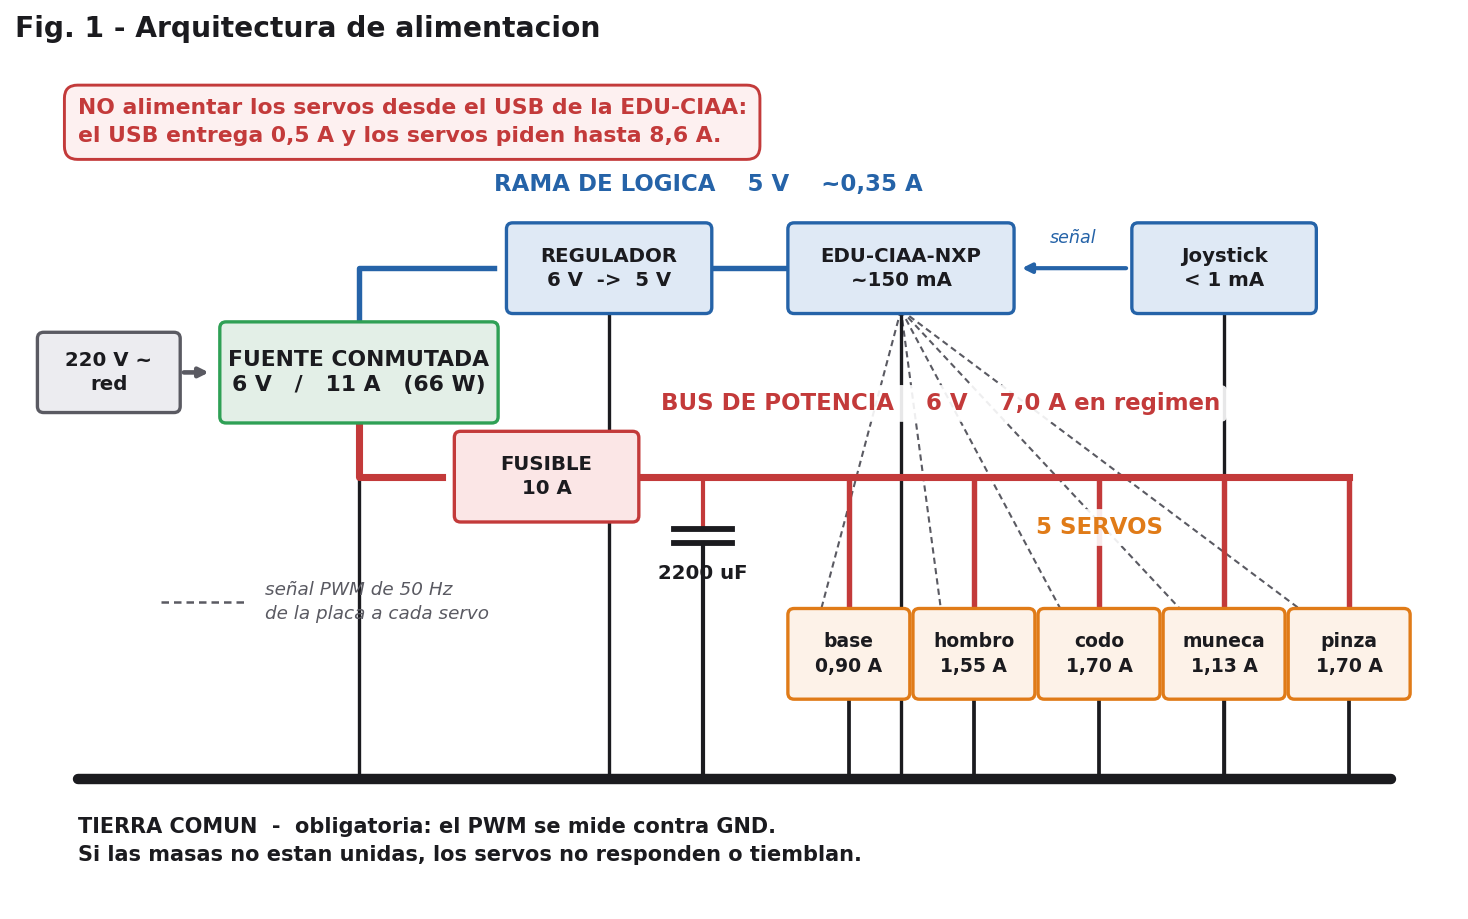

Hay **dos ramas separadas**, y esa separación es la decisión más importante de
todo el documento:

| Rama | Tensión | Consumo | Qué alimenta |
|---|---|---|---|
| **Potencia** | 6 V | 7,0 A en régimen | los cinco servos |
| **Lógica** | 5 V | ~0,35 A | la EDU-CIAA-NXP, el joystick y el margen para lo que se agregue |

El detalle del consumo de la rama de lógica:

| Elemento | Corriente | Origen del dato |
|---|---|---|
| EDU-CIAA-NXP | ~150 mA | consumo típico de la placa con el micro, el puente USB y los LED |
| Joystick (2 potenciómetros) | < 1 mA | dos resistencias de 10 kΩ a 3,3 V |
| **Margen para agregados** | 200 mA | un display, finales de carrera o un relé que se sumen más adelante |
| **Total** | **~0,35 A** | |

El margen de 200 mA lo declaramos ahora a propósito: cuesta lo mismo conseguir
la fuente con él que sin él.

**Los servos se llevan el 95 % del consumo.** Todo el resto del documento es, en
la práctica, sobre ellos.

---

# 2. La tensión: por qué 6 V y no 5 V

La hoja de datos del MG996R da el par de bloqueo en dos tensiones: **9,4 kg·cm a
4,8 V** y **11 kg·cm a 6,0 V**. Entre esos dos puntos el par crece de forma
aproximadamente lineal con la tensión, que es lo que se espera de un motor de
corriente continua.

Eso hay que cruzarlo con lo que le pedimos a cada servo, que viene del cuaderno
de dimensionamiento: el par que hace cada articulación multiplicado por el factor
de seguridad 2.

In [1]:
import math

FS = 2.0                    # el mismo factor de seguridad del cuaderno mecanico
TAU_48, TAU_60 = 9.4, 11.0  # kg.cm, hoja de datos del MG996R

def par_disponible(V):
    '''Par de bloqueo del MG996R interpolado linealmente con la tension.'''
    return TAU_48 + (TAU_60 - TAU_48) * (V - 4.8) / (6.0 - 4.8)

# articulacion, par que realmente hace [kg.cm]
EXIGENCIA = [("hombro", 4.44), ("codo", 5.47), ("muneca", 1.62)]

for V in (4.8, 5.0, 6.0):
    disponible = par_disponible(V)
    print(f"--- alimentando a {V:.1f} V  ->  el servo da {disponible:.2f} kg.cm ---")
    for nombre, tau in EXIGENCIA:
        requerido = tau * FS
        estado = "OK" if disponible >= requerido else "NO CUMPLE"
        print(f"    {nombre:<9} requiere {requerido:5.2f} kg.cm   {estado}")
    print()

--- alimentando a 4.8 V  ->  el servo da 9.40 kg.cm ---
    hombro    requiere  8.88 kg.cm   OK
    codo      requiere 10.94 kg.cm   NO CUMPLE
    muneca    requiere  3.24 kg.cm   OK

--- alimentando a 5.0 V  ->  el servo da 9.67 kg.cm ---
    hombro    requiere  8.88 kg.cm   OK
    codo      requiere 10.94 kg.cm   NO CUMPLE
    muneca    requiere  3.24 kg.cm   OK

--- alimentando a 6.0 V  ->  el servo da 11.00 kg.cm ---
    hombro    requiere  8.88 kg.cm   OK
    codo      requiere 10.94 kg.cm   OK
    muneca    requiere  3.24 kg.cm   OK



**A 5 V no cierra.** El codo se queda por debajo del factor de seguridad que
adoptamos, que es justamente el margen que cubre la dispersión de fabricación y
el desgaste. Alimentar a 5 V significaría gastarnos ese margen antes de empezar.

Por eso la rama de potencia es de **6 V**, y la lógica se alimenta aparte a 5 V.
Tampoco vamos más arriba: la hoja de datos admite hasta 7,2 V, pero por encima
de 6 V el servo se calienta más y no ganamos nada, porque con 11 kg·cm ya
cumplimos.

Notar que el codo queda en 10,93 contra 11 disponibles: **es la articulación
crítica de todo el diseño, y trabaja al 99 % de lo que el criterio permite.**
Volvemos sobre esto en la sección 10.

---

# 3. Cuánta corriente pide un servo

Acá está el atajo que nos permite no exagerar el cálculo.

Adentro de un servo hay un motor de corriente continua, y en un motor de
continua el par es proporcional a la corriente:

$$\tau = k_t \cdot I$$

El servo además consume algo aunque no esté haciendo fuerza: la fricción interna
del tren de engranajes y la electrónica de control. Esa es la corriente **en
marcha sin carga**, que la hoja de datos da como 900 mA a 6 V. El otro extremo,
con el eje bloqueado y el motor haciendo su par máximo, es la **corriente de
bloqueo**: 2,5 A. Entre esos dos puntos la relación es una recta:

$$I(\tau) = I_{sin\,carga} + \left(I_{bloqueo} - I_{sin\,carga}\right)\cdot\frac{\tau}{\tau_{nominal}}$$

Lo importante es lo que esto nos evita: **no necesitamos suponer que los servos
están bloqueados**. Del cuaderno de dimensionamiento sabemos exactamente qué par
hace cada uno, así que podemos calcular la corriente real.

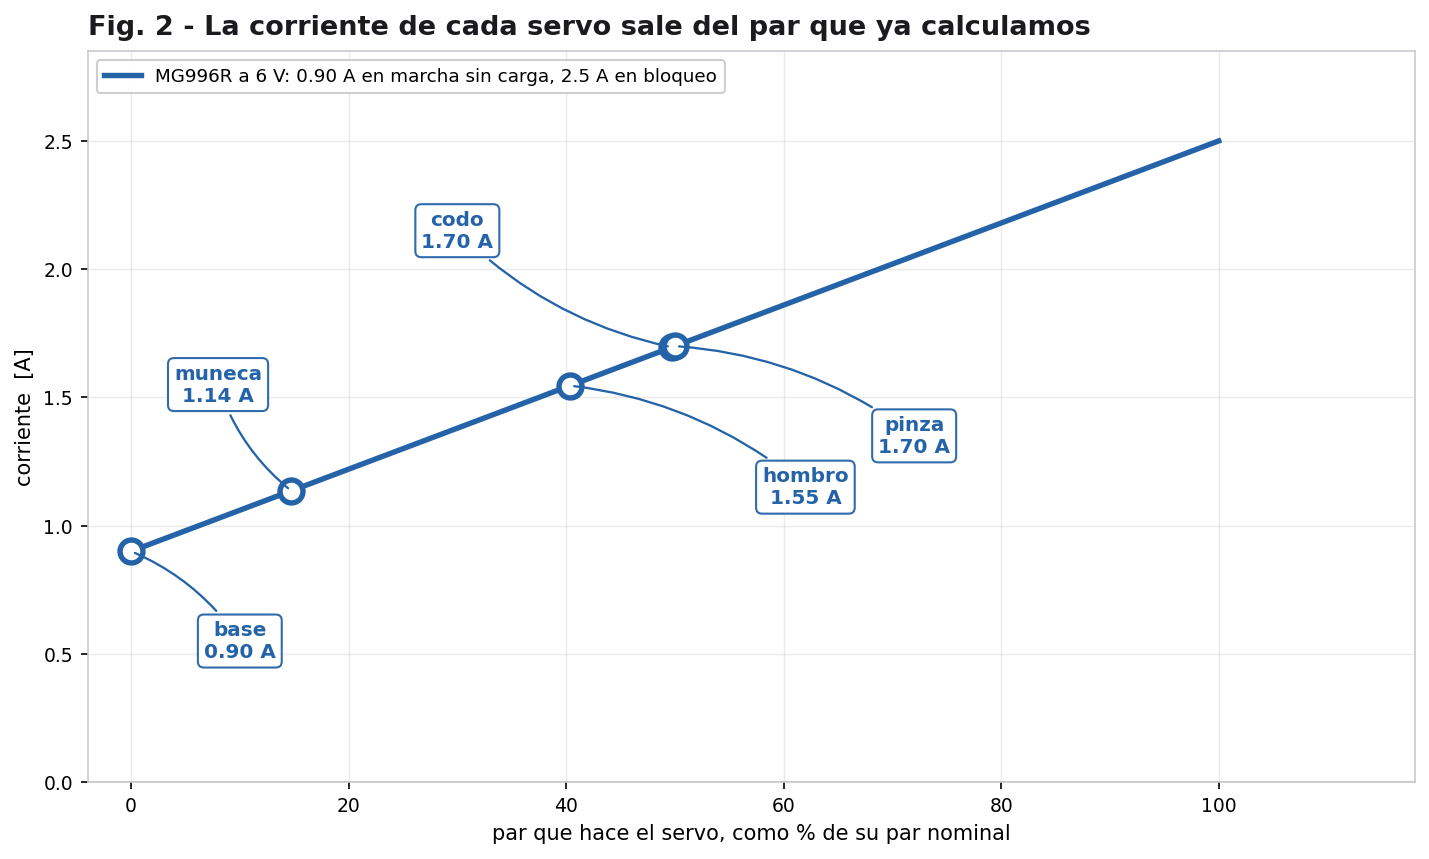

> Los dos extremos de la recta salen de la hoja de datos. Es el dato más flojo
> del cuaderno —los clones no siempre la respetan— y por eso encabeza la lista
> de mediciones de la sección 10. El método no cambia cuando los midamos: solo
> se reemplazan dos números.

In [2]:
# MG996R a 6 V, hoja de datos
I_SIN_CARGA = 0.90          # A, en marcha sin carga
I_BLOQUEO_1 = 2.50          # A, con el eje bloqueado
TAU_NOM = 11.0              # kg.cm

# articulacion y par que hace [kg.cm]  (del cuaderno de dimensionamiento)
SERVOS = [("base",    0.00),    # eje vertical: no tiene par gravitatorio
          ("hombro",  4.44),    # con el resorte compensador
          ("codo",    5.47),
          ("muneca",  1.62),
          ("pinza",   5.50)]    # estimado: sostiene al 50 % de su par

def corriente(tau):
    '''Corriente que consume un MG996R haciendo ese par, a 6 V.'''
    return I_SIN_CARGA + (I_BLOQUEO_1 - I_SIN_CARGA) * (tau / TAU_NOM)

print(f"{'servo':<9}{'par':>10}{'% nominal':>12}{'I regimen':>12}")
print('-' * 43)
I_REGIMEN = 0.0
for nombre, tau in SERVOS:
    i_reg = corriente(tau)
    I_REGIMEN += i_reg
    print(f"{nombre:<9}{tau:>7.2f} kg{tau/TAU_NOM*100:>10.0f} %{i_reg:>9.2f} A")
I_BLOQUEO = len(SERVOS) * I_BLOQUEO_1
print('-' * 43)
print(f"{'SUMA':<9}{'':>10}{'':>12}{I_REGIMEN:>9.2f} A")
print(f"\ncon los cinco bloqueados a la vez seria {I_BLOQUEO:.1f} A")

servo           par   % nominal   I regimen
-------------------------------------------
base        0.00 kg         0 %     0.90 A
hombro      4.44 kg        40 %     1.55 A
codo        5.47 kg        50 %     1.70 A
muneca      1.62 kg        15 %     1.14 A
pinza       5.50 kg        50 %     1.70 A
-------------------------------------------
SUMA                                6.98 A

con los cinco bloqueados a la vez seria 12.5 A


La suma, **7,0 A**, es el consumo del brazo trabajando. Los 12,5 A de los cinco
bloqueados no corresponden a ninguna situación real, pero aparecen por un
instante en el arranque y por eso los calculamos.

Dos filas merecen aclaración:

- La **base** gira sobre un eje vertical, así que no tiene par gravitatorio que
  vencer. Consume su corriente en marcha sin carga, que no es poco: 0,90 A.
- La **pinza** todavía no está dimensionada. Suponemos que sostiene el recipiente
  al 50 % de su par nominal, que es conservador para un agarre por fricción.

Un detalle que salta a la vista en la Fig. 2: **la corriente sin carga es el
término que domina**. Aun con el brazo sin hacer fuerza, los cinco servos en
movimiento consumen 4,5 A. Esa es la diferencia principal con la estimación
preliminar que teníamos antes de fijar el modelo de servo.

---

# 4. El pico de arranque

Cuando un servo arranca desde el reposo, durante unos 150 ms consume una
corriente cercana a la de bloqueo: tiene que acelerar el brazo antes de llegar a
su velocidad de régimen.

Si los cinco arrancan en el mismo instante, esos picos se suman. Si los
escalonamos desde el firmware, no.

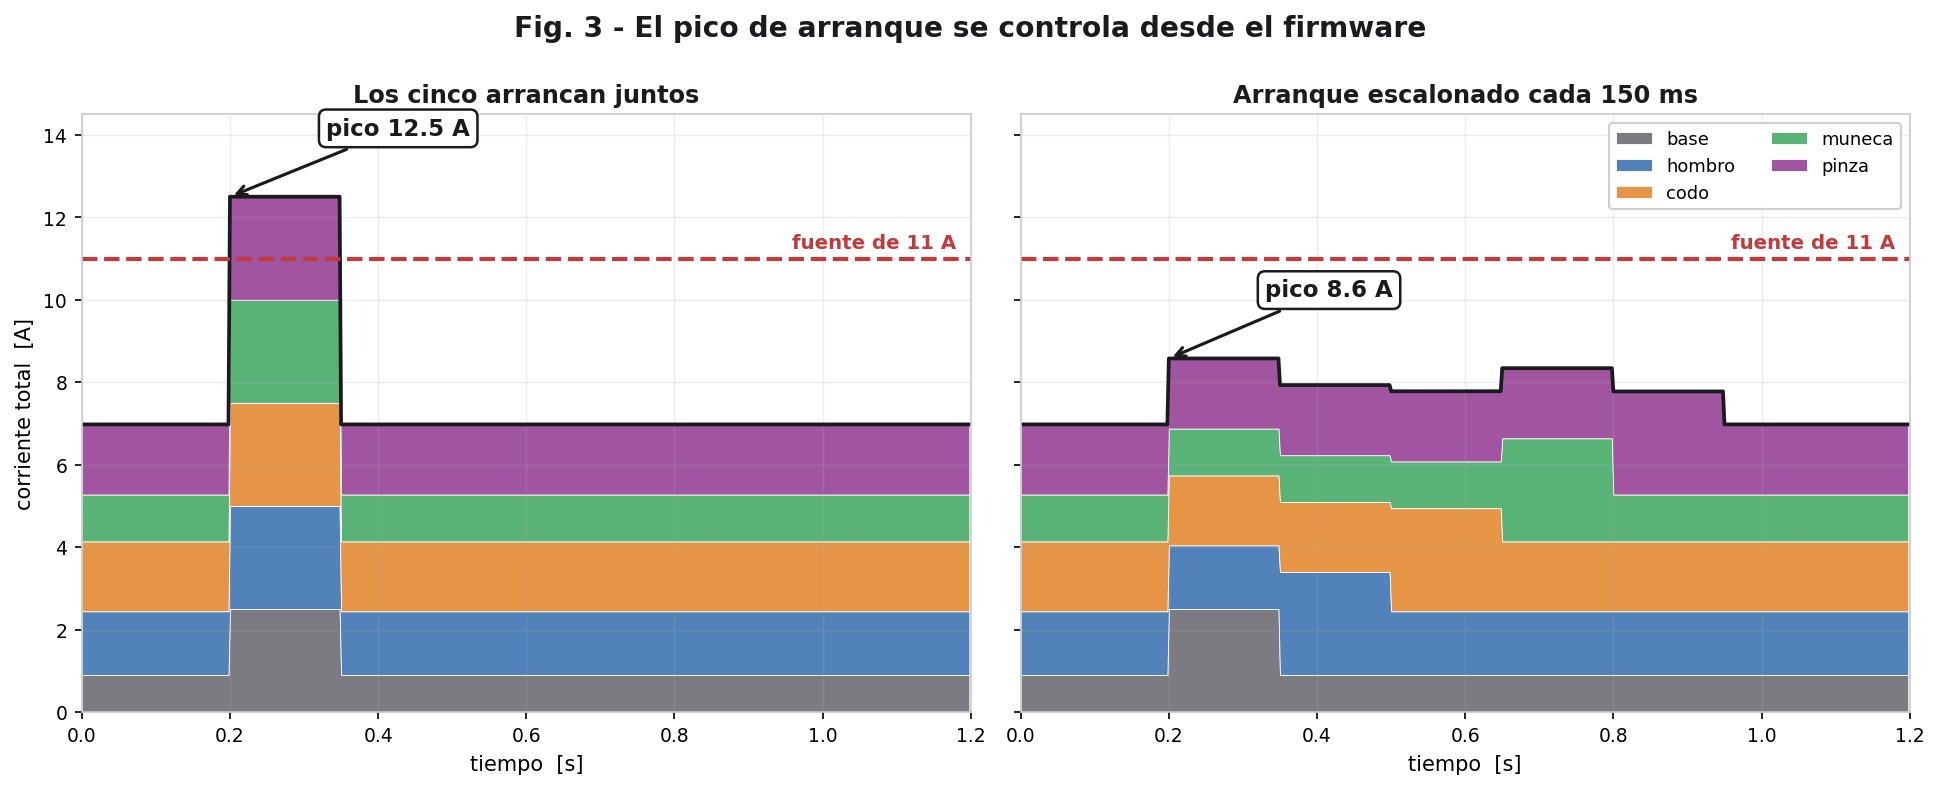

In [3]:
I_PICO_JUNTOS = I_BLOQUEO
# Escalonando, en cada instante hay UN servo arrancando y el resto en regimen
I_PICO_ESCALONADO = I_REGIMEN + (I_BLOQUEO_1 - I_SIN_CARGA)

print(f"pico con los cinco arrancando juntos : {I_PICO_JUNTOS:5.2f} A")
print(f"pico con arranque escalonado         : {I_PICO_ESCALONADO:5.2f} A")
print(f"reduccion                            : "
      f"{100*(1 - I_PICO_ESCALONADO/I_PICO_JUNTOS):5.0f} %")

pico con los cinco arrancando juntos : 12.50 A
pico con arranque escalonado         :  8.58 A
reduccion                            :    31 %


**El escalonado baja el pico un 31 %, y no cuesta nada**: son 150 ms de retardo
entre ejes al arrancar cada movimiento, escritos en el firmware. Contra los 2
segundos que dura el tramo más corto de la trayectoria, es imperceptible para el
operador.

Queda como **requerimiento de software**, igual que los tiempos mínimos de la
trayectoria: *el firmware arranca los ejes escalonados 150 ms*.

---

# 5. Por qué el capacitor no reemplaza al escalonado

La pregunta natural es si se puede evitar el escalonado poniendo un capacitor
grande que absorba el pico. La respuesta es que no, y la cuenta lo muestra en
una línea.

Un capacitor que entrega una corriente $I$ durante un tiempo $\Delta t$ se
descarga una tensión $\Delta V$ según

$$C = \frac{I \cdot \Delta t}{\Delta V}$$

In [4]:
I_FUENTE = 11.0             # A, la fuente que vamos a elegir en la seccion 7

print("CASO 1 - reemplazar el escalonado con un capacitor")
exceso = I_PICO_JUNTOS - I_FUENTE
dt, dv = 0.150, 0.30
C = exceso * dt / dv
print(f"   faltan {exceso:.2f} A durante {dt*1000:.0f} ms, "
      f"con una caida maxima de {dv} V")
print(f"   C = I dt / dV = {C:.3f} F = {C*1e6:,.0f} uF   -> inviable\n")

print("CASO 2 - absorber la conmutacion del motor")
I_conm, dt2, dv2 = 3.0, 100e-6, 0.20
C2 = I_conm * dt2 / dv2
print(f"   {I_conm:.0f} A durante {dt2*1e6:.0f} us, "
      f"con una caida maxima de {dv2} V")
print(f"   C = {C2*1e6:,.0f} uF   -> adoptamos 2200 uF (valor comercial)")

CASO 1 - reemplazar el escalonado con un capacitor
   faltan 1.50 A durante 150 ms, con una caida maxima de 0.3 V
   C = I dt / dV = 0.750 F = 750,000 uF   -> inviable

CASO 2 - absorber la conmutacion del motor
   3 A durante 100 us, con una caida maxima de 0.2 V
   C = 1,500 uF   -> adoptamos 2200 uF (valor comercial)


Tres cuartos de faradio es un valor que no existe en un banco de electrolíticos
razonable: serían más de trescientos capacitores de 2200 µF. **El pico de un
servo dura demasiado como para taparlo con un capacitor.**

El capacitor sí sirve, pero para otra escala de tiempo. El control interno del
servo conmuta el motor a varios kHz, y esos transitorios de decenas de
microsegundos sí los absorbe un capacitor chico. Ahí el número da **1500 µF**, y
adoptamos el valor comercial siguiente, **2200 µF**, montado sobre el bus de
potencia lo más cerca posible de los servos.

Son dos herramientas para dos escalas de tiempo, y ninguna reemplaza a la otra:
el **escalonado** resuelve los 150 ms y el **capacitor** resuelve los 100 µs.

---

# 6. Los cables

Un cable fino no impide que el brazo funcione: hace que la tensión que llega al
servo sea menor que la de la fuente, y como el par crece con la tensión
(sección 2), un cable fino **le quita par al brazo**. Con el codo trabajando al
99 % del criterio, eso importa más que de costumbre.

La resistencia de un cable de cobre es

$$R = \rho\,\frac{L}{S}, \qquad \rho_{cobre} = 0{,}0175\ \frac{\Omega\cdot mm^2}{m}$$

donde $L$ es la longitud total del conductor (ida **y** vuelta) y $S$ la sección.
Adoptamos como criterio que la caída no supere el **3 % de la tensión**, que es
el valor habitual en instalaciones de baja tensión.

In [5]:
RHO = 0.0175                # ohm.mm2/m, cobre
LARGO = 2.0                 # m, ida y vuelta desde la fuente hasta los servos
V_POT = 6.0
CAIDA_MAX = 0.03 * V_POT

R_max = CAIDA_MAX / I_REGIMEN
S_min = RHO * LARGO / R_max
print(f"Caida admitida: {CAIDA_MAX:.2f} V  (3 % de {V_POT:.0f} V)")
print(f"Resistencia maxima del cable: {R_max:.3f} ohm")
print(f"Seccion minima: {S_min:.2f} mm2\n")

print(f"{'seccion':>9}{'R':>9}{'caida':>9}{'':>8}")
for S in (0.50, 0.75, 1.00, 1.50, 2.50):
    R = RHO * LARGO / S
    caida = R * I_REGIMEN
    marca = "OK" if caida <= CAIDA_MAX else "excede"
    print(f"{S:>6.2f} mm2{R:>8.3f}{caida:>8.2f} V {caida/V_POT*100:>5.1f} %"
          f"   {marca}")

Caida admitida: 0.18 V  (3 % de 6 V)
Resistencia maxima del cable: 0.026 ohm
Seccion minima: 1.36 mm2

  seccion        R    caida        
  0.50 mm2   0.070    0.49 V   8.1 %   excede
  0.75 mm2   0.047    0.33 V   5.4 %   excede
  1.00 mm2   0.035    0.24 V   4.1 %   excede
  1.50 mm2   0.023    0.16 V   2.7 %   OK
  2.50 mm2   0.014    0.10 V   1.6 %   OK


Adoptamos **1,5 mm² (AWG 16)** para la rama de potencia. Es el primer valor
comercial que cumple. Es bastante más grueso que lo que uno pondría a ojo, y esa
es exactamente la razón por la que conviene hacer la cuenta: con el cable de
0,5 mm² que viene en los propios servos, la caída sería del 8 % y el codo
dejaría de cumplir.

Los cables de señal (el PWM de cada servo) no llevan corriente apreciable, así
que ahí la sección se elige por resistencia mecánica.

Una regla de armado que vale más que la sección: **conectar los servos en
estrella desde el capacitor, no en cadena**. Si se los conecta uno colgado del
otro, el último de la fila ve la caída de todos los que lo preceden.

---

# 7. La fuente

Ya tenemos los dos números que la definen: la corriente de régimen (7,0 A) y el
pico escalonado (8,6 A).

Sobre la corriente de régimen aplicamos un factor de seguridad de **1,5**, más
chico que el 2 de la parte mecánica porque acá hay menos incertidumbre: la
corriente la vamos a medir. Ese 50 % cubre el derrateo térmico de la fuente, la
tolerancia del fabricante y el aumento de consumo de los servos con el desgaste.

In [6]:
FS_FUENTE = 1.5
I_necesaria = I_REGIMEN * FS_FUENTE

print(f"corriente de regimen      : {I_REGIMEN:5.2f} A")
print(f"x factor de seguridad {FS_FUENTE}  : {I_necesaria:5.2f} A")
print(f"pico escalonado           : {I_PICO_ESCALONADO:5.2f} A")
print(f"\nla fuente tiene que cubrir el mayor de los dos: "
      f"{max(I_necesaria, I_PICO_ESCALONADO):.2f} A")
print(f"ADOPTAMOS: {V_POT:.0f} V / {I_FUENTE:.0f} A "
      f"({V_POT*I_FUENTE:.0f} W)")
print(f"\nconsumo real en regimen: {V_POT*I_REGIMEN:.1f} W "
      f"({100*I_REGIMEN/I_FUENTE:.0f} % de la capacidad de la fuente)")

corriente de regimen      :  6.98 A
x factor de seguridad 1.5  : 10.47 A
pico escalonado           :  8.58 A

la fuente tiene que cubrir el mayor de los dos: 10.47 A
ADOPTAMOS: 6 V / 11 A (66 W)

consumo real en regimen: 41.9 W (63 % de la capacidad de la fuente)


## Especificación completa

| Ítem | Valor adoptado | De dónde sale |
|---|---|---|
| Tensión de potencia | **6 V** | sección 2: a 5 V el codo no cumple el factor de seguridad |
| Corriente en régimen | 7,0 A | sección 3 |
| Pico de arranque | 8,6 A | sección 4, con el escalonado del firmware |
| **Fuente** | **6 V / 11 A (66 W)** | sección 7 |
| Capacitor de bus | 2200 µF | sección 5 |
| Cable de potencia | 1,5 mm² (AWG 16) | sección 6 |
| Fusible | 10 A retardado | sección 9 |
| Tensión de lógica | 5 V / 0,35 A | sección 1 |

Una fuente dedicada de 6 V y 11 A ya no es un componente barato. En la sección 8
evaluamos la alternativa que resuelve eso: reciclar una fuente de PC.

---

# 8. ¿Conviene usar una fuente de PC?

Una fuente ATX en desuso es una opción atractiva: suele conseguirse sin costo,
viene en una caja metálica con ventilador y cables, tiene protecciones de
fábrica y entrega mucha más corriente de la que necesitamos. Con los 11 A que
nos pide el cálculo, deja de ser una curiosidad y pasa a ser la opción sensata.

## 8.1 El problema: la ATX no tiene 6 V

Una fuente ATX entrega +12 V, +5 V, +3,3 V y −12 V. **No hay riel de 6 V**, que
es justamente la tensión que necesitamos. Hay tres formas de salvarlo:

| Camino | Veredicto |
|---|---|
| Usar el riel de +5 V directo | **Descartado.** La sección 2 muestra que a 5 V el codo no cumple el factor de seguridad. |
| Usar +5 V y cambiar el servo del codo por uno más grande | Rompe la decisión de usar un único modelo en las cinco articulaciones, que es lo que simplifica los repuestos, el montaje y el firmware. |
| Usar el riel de +12 V con un convertidor reductor a 6 V | **Viable**, y es el camino que analizamos abajo. |

## 8.2 La variante híbrida

Si vamos a usar la ATX, conviene aprovechar los dos rieles:

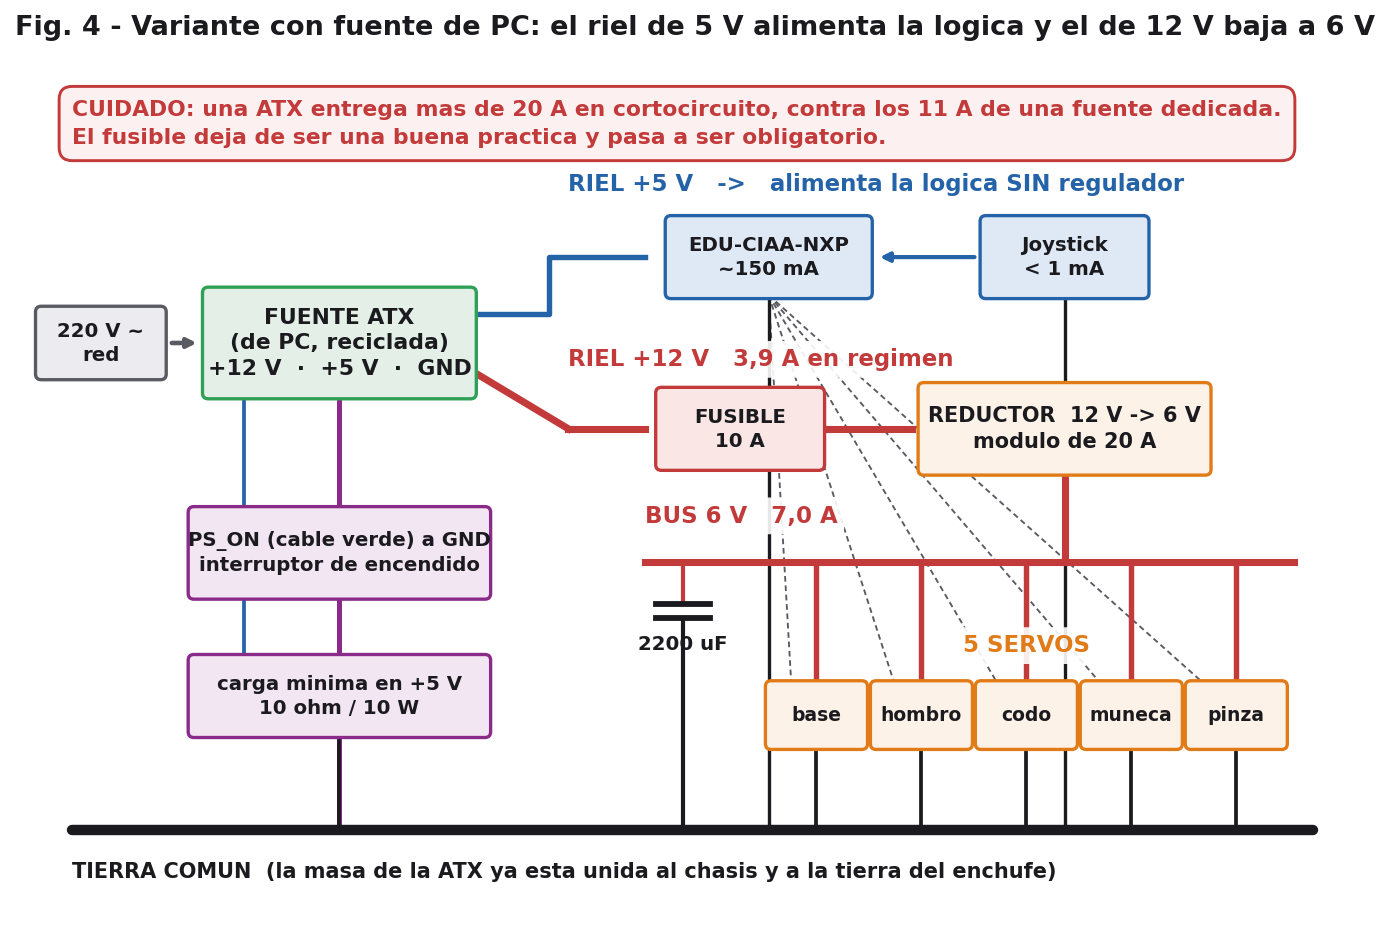

El riel de **+5 V alimenta la lógica directamente**, ya regulado y con corriente
de sobra. Eso nos ahorra el regulador de la arquitectura original: un componente
menos que montar y que puede fallar.

El riel de **+12 V pasa por el fusible y por un reductor** que baja a 6 V para
los servos. De ahí en adelante todo es igual: capacitor sobre el bus y los cinco
servos en estrella.

## 8.3 Qué tiene que aguantar el reductor

In [7]:
V_ATX = 12.0
ETA_BUCK = 0.90             # rendimiento tipico de un modulo reductor

print(f"{'condicion':<20}{'P salida':>11}{'P entrada':>12}"
      f"{'I desde 12 V':>15}{'disipa':>10}")
print('-' * 68)
for etiqueta, I_out in (("regimen", I_REGIMEN),
                        ("pico escalonado", I_PICO_ESCALONADO)):
    P_out = V_POT * I_out
    P_in = P_out / ETA_BUCK
    print(f"{etiqueta:<20}{P_out:>9.1f} W{P_in:>10.1f} W"
          f"{P_in/V_ATX:>13.2f} A{P_in - P_out:>8.1f} W")

condicion              P salida   P entrada   I desde 12 V    disipa
--------------------------------------------------------------------
regimen                  41.9 W      46.5 W         3.88 A     4.7 W
pico escalonado          51.5 W      57.2 W         4.77 A     5.7 W


El reductor tiene que estar especificado para **al menos el pico de 8,6 A**, y
conviene tomar un módulo de **20 A**: la corriente que declaran estos módulos es
optimista y se sostiene solo con disipador y ventilación. Disipando entre 5 y
6 W, el disipador no es opcional.

Del lado de la ATX el consumo es de 3,9 A sobre un riel de 12 V que en cualquier
fuente entrega 15 A o más.

## 8.4 Cómo se enciende una ATX

Una fuente de PC no arranca al enchufarla: espera la orden de la placa madre.
Hay que hacer dos cosas:

1. **Puentear PS_ON a masa.** Es el cable verde del conector de 24 pines; se une
   a cualquier cable negro. Conviene hacerlo a través de un interruptor, que
   pasa a ser el encendido del brazo.
2. **Poner una carga mínima en el riel de +5 V** si la fuente no arranca sola.
   Las fuentes viejas necesitan consumo para regular; una resistencia de 10 Ω y
   10 W alcanza. Las modernas suelen arrancar sin esto, así que es un agregado
   condicional: se prueba primero sin ella.

Un detalle a favor: la masa de la ATX ya está unida al chasis y a la tierra del
enchufe, así que la tierra común de la sección 9 queda resuelta por
construcción.

## 8.5 Los dos riesgos que agrega

**Uno. La capacidad de cortocircuito.** Una fuente dedicada de 11 A, ante un
error de cableado, entrega 11 A y se protege sola. Una ATX entrega **más de
20 A** y va a alimentar el error hasta que algo se queme: el cable, un servo o
la pista de una placa. Con ATX, el fusible de 10 A deja de ser una buena
práctica y pasa a ser **obligatorio**, y tiene que estar lo más cerca posible de
la fuente.

**Dos. El preset del reductor.** Estos módulos se ajustan con un potenciómetro
en miniatura. Si ese preset se mueve —con una vibración, con un destornillador,
con un cable que lo roza— la salida puede subir a 12 V y quemar los cinco servos
de una sola vez. El procedimiento que lo evita:

1. Alimentar el reductor **sin nada conectado a la salida**.
2. Ajustar a 6,0 V midiendo con multímetro.
3. Sellar el preset con laca o pegamento.
4. Volver a medir, y **recién ahí** conectar el primer servo.

## 8.6 Las dos opciones, lado a lado

| | Fuente dedicada 6 V / 11 A | Fuente ATX + reductor |
|---|---|---|
| Costo | se compra, y a 11 A no es barata | la ATX suele estar en desuso; se suma el reductor |
| Tensión de los servos | fija de fábrica en 6 V | ajustable: hay que calibrarla y fijarla |
| Rama de lógica | necesita un regulador 6 V → 5 V | sale del riel de +5 V, sin componentes |
| Corriente disponible | 11 A | decenas de amperes |
| Ante un cortocircuito | limitada, se protege sola | más de 20 A: el fusible es obligatorio |
| Piezas a montar | fuente, fusible, capacitor, regulador | ATX, interruptor PS_ON, carga mínima, fusible, reductor con disipador, capacitor |
| Modo de falla nuevo | ninguno | el preset del reductor puede subir la salida a 12 V |
| Tamaño y ruido | chica y silenciosa | voluminosa, con ventilador |

## 8.7 Qué adoptamos

**Usamos la fuente de PC.** Con el consumo real del brazo en 7 A, una fuente
dedicada de 11 A cuesta bastante más que un reductor, y la ATX además nos
resuelve la lógica y la tierra común sin componentes. Las tres condiciones no
son negociables: fusible de 10 A junto a la fuente, reductor de 20 A con
disipador, y el preset ajustado y sellado antes de conectar el primer servo.

Si para la entrega final el brazo tiene que quedar prolijo o transportable, se
reemplaza por la fuente dedicada de la sección 7 sin tocar nada más del diseño:
el bus de 6 V, el capacitor, el cable y el fusible son los mismos.

---

# 9. Protecciones y reglas de cableado

Estas son decisiones de armado. Ninguna sale de un cálculo, pero todas evitan un
modo de falla concreto.

| Medida | Qué previene |
|---|---|
| **Fusible de 10 A retardado** en la rama de potencia | Un cortocircuito en el cableado de los servos. Es retardado para que no corte con el pico de 8,6 A del arranque, y está por debajo de lo que tolera el cable de 1,5 mm². Con la fuente de PC de la sección 8 deja de ser opcional. |
| **Tierra común entre las dos ramas** | El PWM se mide contra GND. Si las masas no están unidas, los servos no responden o tiemblan. Es el error de cableado más frecuente en este tipo de montaje. |
| **No alimentar los servos desde el USB de la EDU-CIAA** | El USB entrega 0,5 A y los servos piden hasta 8,6 A. La placa se resetea, o se daña el puerto de la PC. |
| **Conector polarizado en la entrada de 6 V** | Invertir la polaridad quema los cinco servos de una vez. |
| **Interruptor de corte que abra solo la rama de potencia** | Permite frenar el brazo dejando la lógica viva, para que el firmware sepa que se cortó y no intente seguir moviéndose al volver la tensión. |
| **Capacitor sobre el bus** | Además de lo de la sección 5, absorbe la energía que los servos devuelven al frenar. |

---

# 10. Qué hay que medir

Todo este cuaderno se apoya en **dos números de la hoja de datos** —la corriente
en marcha sin carga y la de bloqueo— y en un par de bloqueo de 11 kg·cm que los
clones no siempre respetan. Son el eslabón más débil y hay que confirmarlos.

Las mediciones se pueden hacer junto con el ensayo mecánico de la junta, sin
tener el brazo completo:

1. **Par de bloqueo real del servo.** Es la medición más importante, porque el
   codo trabaja al 99 % del criterio. Con el servo sujeto y un brazo de palanca
   conocido, se cuelga peso hasta que el servo cede. Si el servo real da menos
   de 11 kg·cm, hay que bajar la carga del recipiente o acortar los eslabones.
2. **Corriente en marcha sin carga.** Multímetro en serie con la alimentación de
   un solo servo, moviéndose sin carga.
3. **Corriente de bloqueo.** El mismo montaje, trabando el eje con la mano un
   instante breve. Hay que ser rápido: bloqueado, un servo se calienta en
   segundos.
4. **Corriente con la carga real**, con el brazo de ensayo y la pesa en la punta.
   Es el valor a comparar contra la columna «I régimen» de la sección 3.
5. **Caída en el cable.** Medir la tensión en los bornes del servo más lejano,
   con el brazo en su pose de mayor esfuerzo, y verificar que no baje más del
   3 % respecto de la fuente.

Con esas cinco mediciones el cuaderno deja de apoyarse en hojas de datos y pasa
a apoyarse en datos propios. Si los valores difieren, solo hay que reemplazar
las constantes de la sección 3 y volver a ejecutar: todo lo demás se recalcula
solo.

### Lo que queda pendiente

- **Dimensionar la pinza**, que arrastra la estimación del 50 % de par que usamos
  en la sección 3. Es el único servo cuyo consumo no está atado a un cálculo.
- **Elegir el reductor** de 12 V a 6 V y su disipador, una vez confirmado que se
  usa la fuente de PC.